In [1]:
import numpy as np
from numpy import genfromtxt
import matplotlib.pyplot as plt
import random

In [2]:
data = genfromtxt("advertising.csv", delimiter=',', skip_header=1)
N = data.shape[0]
X = data[:, :3]
y = data[:, 3:]
print(X[:5])
print(y[:5])

[[230.1  37.8  69.2]
 [ 44.5  39.3  45.1]
 [ 17.2  45.9  69.3]
 [151.5  41.3  58.5]
 [180.8  10.8  58.4]]
[[22.1]
 [10.4]
 [12. ]
 [16.5]
 [17.9]]


In [3]:
def mean_normalization(X):
    N = len(X)
    maxi = np.max(X)
    mini = np.min(X)
    avg = np.mean(X)
    X = (X - avg) / (maxi - mini)
    X_b = np.c_[np.ones((N, 1)), X]
    return X_b, maxi, mini, avg

X_b, maxi, mini, avg = mean_normalization(X)

In [4]:
def initialize_params(length):
    res = []
    for i in range(length+1):
        x = random.gauss(mu=0.0, sigma=0.01)
        res.append(x)
    return res;

In [5]:
def prediction(w, x, b):
    n = x.shape[0]
    m = x.shape[1]
    y_hat = []
    for i in range(n):
        tmp = 0
        for j in range(m):
            tmp += w[j] * x[i][j]
        tmp += b
        y_hat.append(tmp)
    res = np.array(y_hat)
    return res


In [6]:
def MSE(n, pred, y):
    loss = 0
    for i in range(len(y)):
        loss += ((pred[i] - y[i]) * (pred[i] - y[i]))
    loss /= n
    return loss

In [7]:
def derivative(n, x, pred, y):
    res = np.zeros(x.shape[1])

    for i in range(len(pred)):
        error = pred[i] - y[i]
        res += 2 * x[i] * error
    res /= n

    return res

def derivative_b(n, pred, y):
    res = 0
    mean = 0
    for i in range(len(pred)):
        mean += (pred[i] - y[i])
    mean /= n
    
    res = 2 * mean
    return res

In [8]:
def update(w, lr, gd):
    thetas = []
    # print(">>", gd)
    for i in range(len(gd)):
        thetas.append(w[i] - lr * gd[i])
    # print(">>", thetas)
    return thetas

def update_b(b, lr, gd_b):
    return b - lr * gd_b

In [9]:
def mini_batch_gradient_descent(X, y, n_epochs=50, minibatch_size=20, lr=0.01):
    N, d_plus1 = X_b.shape
    #print(d_plus1)
    thetas = initialize_params(d_plus1)
    #print(thetas)
    thetas_path = [thetas.copy()]
    losses = []
    for epoch in range(n_epochs):
        shuffled_indices = np.random.permutation(N)
        X_shuffled = X[shuffled_indices]
        y_shuffled = y[shuffled_indices]
        y_shuffled = y_shuffled.ravel()
        
        for i in range(0, N, minibatch_size):
            xi = X_shuffled[i:i+minibatch_size]
            yi = y_shuffled[i:i+minibatch_size]
            # print(thetas)
            #pred
            pred = prediction(thetas, xi, thetas[len(thetas)-1])
            # print("type:", type(pred))
            # print("shape:", np.shape(pred))
            # print("first:", pred[0])
            #print(len(pred))
            #mse
            mse = MSE(minibatch_size, pred, yi)
            #print("MSE: ", mse)
            #gradient
            gd = derivative(minibatch_size, xi, pred, yi)
            gd_b = derivative_b(minibatch_size, pred, yi)
            # print("gd: ", gd)
            # print(len(gd))
            #update
            # print("BEFORE:", thetas)
            thetas = update(thetas, lr, gd)
            # print("AFTER :", thetas)
            # print()
            thetas[len(thetas)-1] = update_b(thetas[len(thetas)-1], lr, gd_b)
            
            thetas_path.append(thetas)
            losses.append(mse)
    return thetas_path, losses

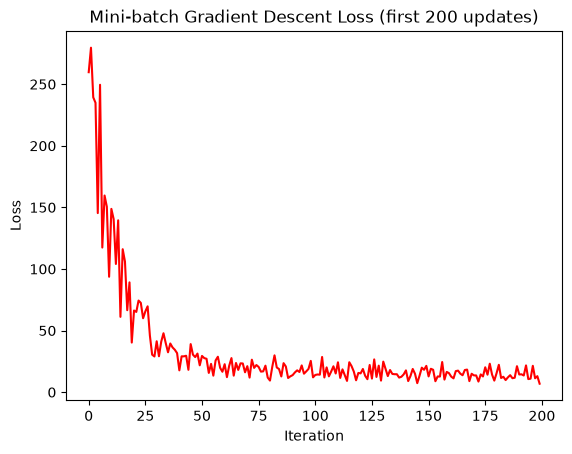

In [10]:
mbgd_thetas, losses = mini_batch_gradient_descent(X_b, y)

# visualize
x_axis = list(range(200))
plt.plot(x_axis, losses[:200], color="r")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Mini-batch Gradient Descent Loss (first 200 updates)")
plt.show()